In [1]:
import os

os.environ["TORCH_BLAS_PREFER_HIPBLASLT"] = "1"
os.environ["TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL"] = "1"

In [2]:
import os

os.environ["TORCH_BLAS_PREFER_HIPBLASLT"] = "1"

import torch

print("PyTorch:", torch.__version__)
print("ROCm:", torch.version.hip)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+rocm10.0.0
ROCm: 7.15.26333
GPU: AMD Radeon 8060S Graphics


In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
AMD Radeon 8060S Graphics


In [4]:
import time
import torch

device = "cuda"

model = torch.nn.Sequential(
    torch.nn.Linear(2, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 1),
).to(device)

# VERY large batch to give the GPU real work
x = torch.randn(1_000_000, 2, device=device)

# Warmup
for _ in range(10):
    model(x)

torch.cuda.synchronize()

start = time.perf_counter()

for _ in range(100):
    model(x)

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

print(f"Total: {elapsed:.3f} s")
print(f"Per forward: {elapsed/100*1000:.3f} ms")

Total: 2.084 s
Per forward: 20.845 ms


In [5]:
import torch
torch.cuda.is_available()

True

In [6]:
from sklearn.datasets import make_circles

n_samples=1000

X,y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values)


In [7]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [10]:
# Check different labels
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

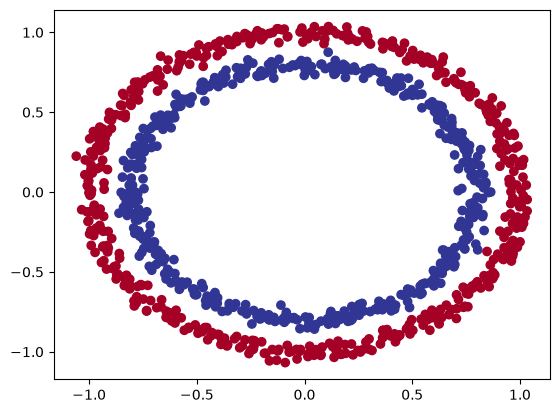

In [11]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

In [12]:
X.shape, y.shape

((1000, 2), (1000,))

In [13]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [14]:
X[:5],y[:5]


(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [15]:
X.shape, y.shape, X.dtype,y.dtype

(torch.Size([1000, 2]), torch.Size([1000]), torch.float32, torch.float32)

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,
                                               random_state=42

)

In [17]:
X_train[:5],X_test[:5],y_train[:5],y_test[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438]]),
 tensor([1., 0., 0., 0., 1.]),
 tensor([1., 0., 1., 0., 1.]))

In [ ]:
import torch
from torch import nn

class BinaryClassification(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1=nn.Linear(in_features=2,out_features=128)# we tried 5 but didnt get expected result
    self.layer2=nn.Linear(in_features=128,out_features=128)
    self.layer3=nn.Linear(in_features=128,out_features=1)

  def forward(self, X):
    return self.layer3(self.layer2(self.layer1(X)))

model1 = BinaryClassification()
model1

BinaryClassification(
  (layer1): Linear(in_features=2, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=1, bias=True)
)

In [19]:
# Replicate CircleModelV0 with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
model1.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.3376, -0.0076],
                      [ 0.6704,  0.3307],
                      [ 0.4311,  0.5870],
                      [-0.1530, -0.4382],
                      [ 0.2268,  0.1503],
                      [-0.5386, -0.3435],
                      [-0.4549,  0.7001],
                      [-0.5744,  0.4149],
                      [-0.2201,  0.0095],
                      [-0.6950,  0.0153],
                      [-0.2264,  0.2303],
                      [-0.1905,  0.0989],
                      [-0.0137, -0.1380],
                      [ 0.0143, -0.0802],
                      [ 0.2668,  0.2179],
                      [ 0.0368,  0.2908],
                      [-0.4545, -0.1827],
                      [-0.2551,  0.3922],
                      [ 0.2352,  0.2355],
                      [-0.2108, -0.1585],
                      [ 0.4299,  0.4829],
                      [ 0.5418, -0.0902],
                      [ 0.5469,  0.3102],
   

In [21]:
# 1. Setup the Loss Function
# We use BCEWithLogitsLoss because our model outputs raw numbers (logits),
# and this function handles the probability conversion safely.
loss_fn = nn.BCEWithLogitsLoss()

# 2. Setup the Optimizer
# We pass in model_0.parameters() so the optimizer knows WHICH weights to update.
# lr=0.1 is the learning rate (how big of a step we take down the hill).
optimizer = torch.optim.Adam(params=model1.parameters(), lr=0.1)

In [22]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
AMD Radeon 8060S Graphics


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = model1.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [25]:
print("Model:", next(model1.parameters()).device)
print("X_train:", X_train.device)
print("y_train:", y_train.device)
print("X_test:", X_test.device)
print("y_test:", y_test.device)

Model: cuda:0
X_train: cuda:0
y_train: cuda:0
X_test: cuda:0
y_test: cuda:0


In [26]:
torch.manual_seed(42)
# Training
epochs=1000
for epoch in range(epochs):
  epoch=epoch+1
  model1.train()
  y_preds=model1(X_train).squeeze() # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device
  loss=loss_fn(y_preds,y_train)
  optimizer.zero_grad()
  #Backward pass (calculate gradients)
  loss.backward()
  #update weights
  optimizer.step()

  #Testing
  model1.eval()
  with torch.inference_mode():
    y_preds_test=model1(X_test).squeeze()
    test_loss=loss_fn(y_preds_test,y_test)

  if epoch%100==0:
    print(f"Epochs: {epoch} | Training_loss: {loss} | Testing_loss:{test_loss}")

Epochs: 100 | Training_loss: 0.6930004954338074 | Testing_loss:0.6943745017051697
Epochs: 200 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946784257888794
Epochs: 300 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946795582771301
Epochs: 400 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946795582771301
Epochs: 500 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946795582771301
Epochs: 600 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946795582771301
Epochs: 700 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946795582771301
Epochs: 800 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946795582771301
Epochs: 900 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946795582771301
Epochs: 1000 | Training_loss: 0.6929798722267151 | Testing_loss:0.6946795582771301


In [27]:
print(X_train.device)
print(y_train.device)
print(next(model1.parameters()).device)

cuda:0
cuda:0
cuda:0


In [28]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


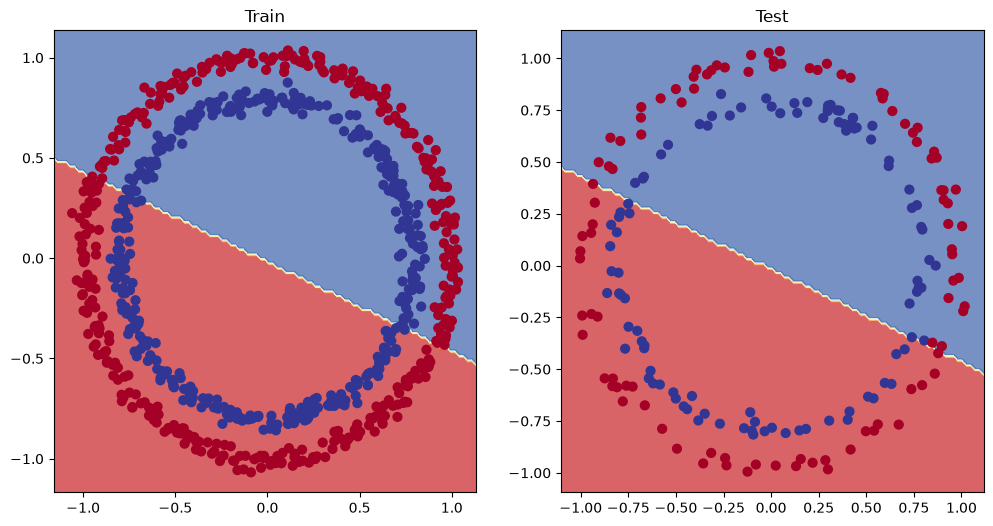

In [29]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model1, X_test, y_test)

In [30]:
# why we used squeeze?
#without squeeze
with torch.inference_mode():
    y_preds_test=model1(X_test)
y_preds_test[:5],y_test[:5],y_preds_test.shape, y_test.shape

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

In [ ]:
# if you see above we have y_pred and y_test dont have same shape.
#So, if we implement loss function(some maths operation) on it, it will fail.
#We need to squeeze() it, which means remove the 1dimension
with torch.inference_mode():
    y_preds_test=model1(X_test)
    test_loss=loss_fn(y_preds_test,y_test)

ValueError: Target size (torch.Size([200])) must be the same as input size (torch.Size([200, 1]))

In [ ]:
# second thing, if you see the training loss and testing loss is not decreasing much
# We have increased the number of hidden layers to 128 and from 2 layers to 3 layers , but still the same result.


Why linear layers alone aren’t enough?
Each layer in a neural network computes:
z = Wx + b (a linear/affine transformation)

If you stack multiple layers without an activation function, the whole network mathematically collapses into a single linear transformation:

y = W₂(W₁x + b₁) + b₂ = (W₂W₁)x + (W₂b₁ + b₂)
No matter how many layers or neurons you add, the model can only learn linear relationships. Depth becomes meaningless.

What activation functions do
By applying a non-linear function after each linear step (a = σ(z)), you:

Break the linear chain → the composition of layers is no longer equivalent to a single linear function
Enable curved, complex decision boundaries → the network can model non-linear patterns (e.g., XOR, circles, hierarchical features)
Unlock depth → stacking non-linear layers allows the network to learn hierarchical representations (edges → shapes → objects, or simple words → syntax → semantics)
Universal Approximation Theorem: A feedforward network with just one hidden layer and a non-linear activation function can approximate any continuous function to arbitrary accuracy (given enough neurons).

⚠️ Important nuance
Not all activation functions are non-linear. If you use a linear activation (σ(z) = z) in hidden layers, you immediately lose the benefit of depth. The network reverts to a single linear model, regardless of architecture size.


## Lets use activation functions now

In [ ]:
import torch 
from sklearn.datasets import make_circles

n_samples=1000

X,y=make_circles(n_samples,
                  noise=0.03,
                  random_state=42)

In [ ]:
X[:5], y[:5], X.shape, y.shape

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]),
 (1000, 2),
 (1000,))

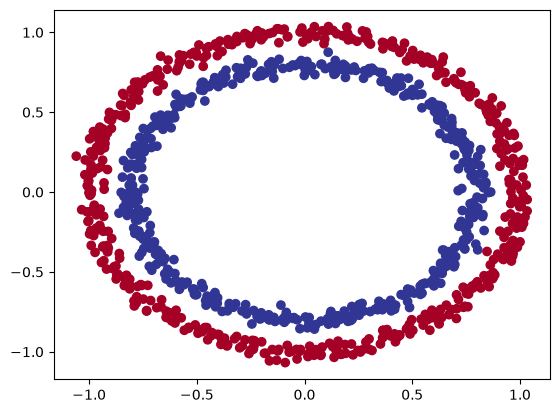

In [ ]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu);

In [ ]:
# first step is to convert data into tensors
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
# once we get the tensor data, we split the data into train,test
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.2,
                                               random_state=42)



In [ ]:
X_train[:5],y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [ ]:
#2nd step: Build the model

from torch import nn

class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(in_features=2, out_features=10)
        self.layer2=nn.Linear(in_features=10, out_features=10)
        self.layer3=nn.Linear(in_features=10, out_features=1)
        self.relu=nn.ReLU()
    
    def forward(self, x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model2=BinaryClassifier()
model2

BinaryClassifier(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(params=model2.parameters(), lr=0.1)

In [ ]:
#Training loop
epochs=1000

for epochs in range(epochs):
    epochs+=1
    model2.train()
    y_preds=model2(X_train).squeeze()
    loss=loss_fn(y_preds,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #Testing
    model2.eval()
    with torch.inference_mode():
        y_preds_test=model2(X_test).squeeze()
        test_loss=loss_fn(y_preds_test,y_test)
    
    if epochs%100==0:
        print(f"Epochs: {epochs} | Training_loss: {loss} | Testing_loss:{test_loss}")

Epochs: 100 | Training_loss: 0.0017025680281221867 | Testing_loss:0.0074180904775857925
Epochs: 200 | Training_loss: 0.0007184860296547413 | Testing_loss:0.005420250818133354
Epochs: 300 | Training_loss: 0.0004135628114454448 | Testing_loss:0.004940158221870661
Epochs: 400 | Training_loss: 0.0002604407200124115 | Testing_loss:0.005725855007767677
Epochs: 500 | Training_loss: 0.0001769963273545727 | Testing_loss:0.005166427697986364
Epochs: 600 | Training_loss: 0.00013103436504025012 | Testing_loss:0.005130435805767775
Epochs: 700 | Training_loss: 0.00010202088742516935 | Testing_loss:0.005339278373867273
Epochs: 800 | Training_loss: 8.212729153456166e-05 | Testing_loss:0.00559327844530344
Epochs: 900 | Training_loss: 6.762451084796339e-05 | Testing_loss:0.005768978968262672
Epochs: 1000 | Training_loss: 5.66617090953514e-05 | Testing_loss:0.005877051502466202


We will look into this later overfitting and underfitting. How can we overcome like early stop.

In [ ]:
# Make predictions
model2.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model2(X_test))).squeeze()
y_preds[:10], y[:10] # want preds in same format as truth labels

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

In [ ]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


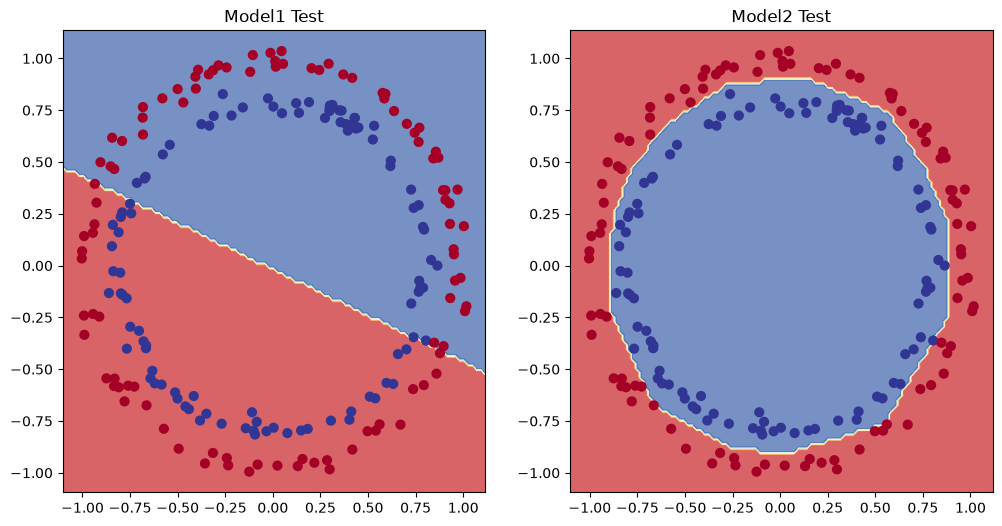

In [ ]:
# Plot decision boundaries for training and test sets
import matplotlib.pyplot as plt
from helper_functions import plot_decision_boundary, plot_predictions

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Model1 Test")
plot_decision_boundary(model1, X_test, y_test) # model1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Model2 Test")
plot_decision_boundary(model2, X_test, y_test) # model2 = has non-linearity

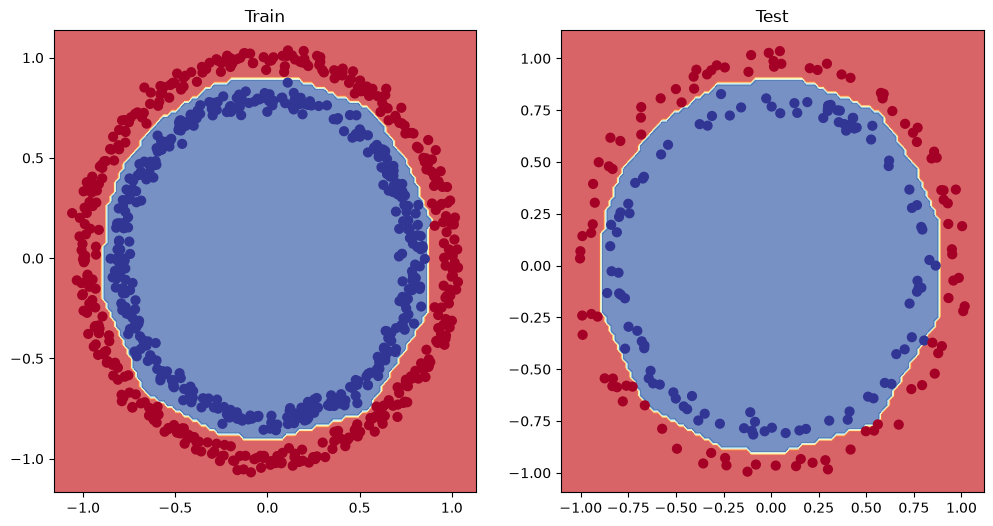

In [ ]:
# Plot decision boundaries for training and test sets
import matplotlib.pyplot as plt
from helper_functions import plot_decision_boundary, plot_predictions

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model2, X_train, y_train) # model1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model2, X_test, y_test) # model2 = has non-linearity

### 7. Replicating non-linear activation functions
We saw before how adding non-linear activation functions to our model can help it to model non-linear data.

Note: Much of the data you'll encounter in the wild is non-linear (or a combination of linear and non-linear). Right now we've been working with dots on a 2D plot. But imagine if you had images of plants you'd like to classify, there's a lot of different plant shapes. Or text from Wikipedia you'd like to summarize, there's lots of different ways words can be put together (linear and non-linear patterns).

But what does a non-linear activation look like?

How about we replicate some and what they do?

Let's start by creating a small amount of data.

In [ ]:
# Create a toy tensor (similar to the data going into our model(s))
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

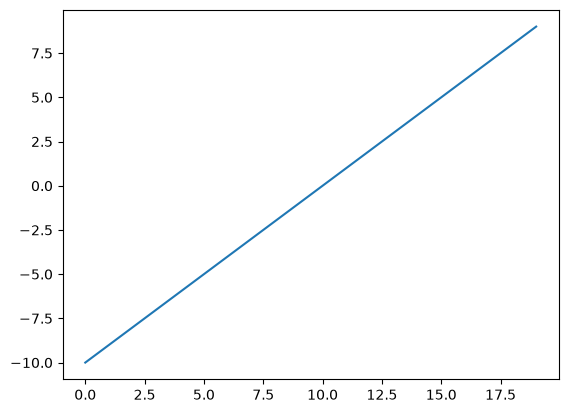

In [ ]:
# Visualize the toy tensor
plt.plot(A);

A straight line, nice.

Now let's see how the ReLU activation function influences it.

And instead of using PyTorch's ReLU (torch.nn.ReLU), we'll recreate it ourselves.

The ReLU function turns all negatives to 0 and leaves the positive values as they are.

In [ ]:
# Create ReLU function by hand 
def relu(x):
  return torch.maximum(torch.tensor(0), x) # inputs must be tensors

# Pass toy tensor through ReLU function
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

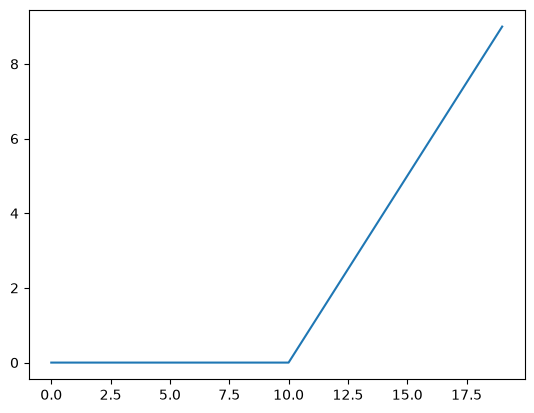

In [ ]:
# Plot ReLU activated toy tensor
plt.plot(relu(A));

How about we try the sigmoid function we've been using?

In [ ]:
# Create a custom sigmoid function
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

# Test custom sigmoid on toy tensor
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

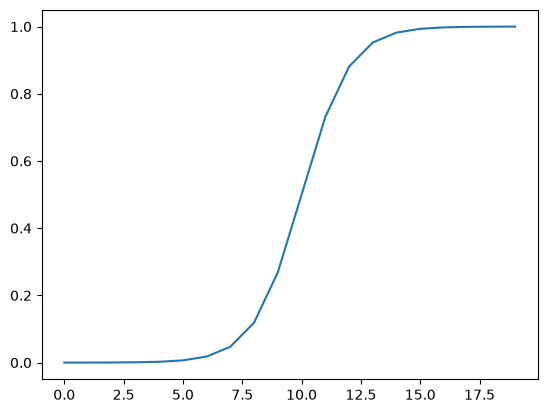

In [ ]:
# Plot sigmoid activated toy tensor
plt.plot(sigmoid(A));